## Final Project
### Regression Analysis
### Author: Brenda Fuemmeler
### Date: November 21, 2025

## Objective
### To use the AutoMPG dataset to demonstrate how to apply regression modeling techniques to real-world data.
### Can we predict fuel efficiency based on engine specs and weight?

# Imports

In [76]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Section 1. Import and Inspect the Data
1.1 Load the dataset and display the first 10 rows.
1.2 Check for missing values and display summary statistics.

In [77]:
# Load the data
data_frame = pd.read_csv("autompg.csv")

# Might be large. Display just the first 10 rows
data_frame.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
5,15.0,8,429.0,198,4341,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220,4354,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215,4312,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225,4425,10.0,70,1,pontiac catalina
9,15.0,8,390.0,190,3850,8.5,70,1,amc ambassador dpl


# Reflection 1: What do you notice about the dataset? Are there any data issues?
The display of the first 10 rows does not show any missing values or major issues. But we know by scanning the dataset there are missing values and issues with categorical vs numerical.

## Section 2. Data Exploration and Preparation
### Before we can explore further, we need to make a few corrections to our data to make it more usable. We will move these steps to the top before continuing.
## 1. Handle missing values and clean data
### Fix 1: Horsepower is showing as a string, so we need to convert to float.
### Fix 2: When identifying numeric vs categorical columns, we found "car name" is categorical. Since this column is likely to cause issues, we will drop this variable.

In [78]:
# Replace "?" with NaN safely by converting horsepower to a float
data_frame['horsepower'] = data_frame['horsepower'].replace("?", np.nan)

# Convert column to numeric safely
data_frame['horsepower'] = pd.to_numeric(data_frame['horsepower'])

In [79]:
# Identify which columns are numeric or categorical
numeric_cols = data_frame.select_dtypes(include=[np.number]).columns
categorical_cols = data_frame.select_dtypes(exclude=[np.number]).columns

numeric_cols, categorical_cols

(Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
        'acceleration', 'model year', 'origin'],
       dtype='object'),
 Index(['car name'], dtype='object'))

In [80]:
# Drop "car name" is it is a string column that we do not want as a variable due to issues it will cause
data_frame.drop("car name", axis=1, inplace=True)

In [81]:
# Recheck numeric vs categorical columns to make sure "car name" has been dropped.
numeric_cols = data_frame.select_dtypes(include=[np.number]).columns
categorical_cols = data_frame.select_dtypes(exclude=[np.number]).columns

numeric_cols, categorical_cols

(Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
        'acceleration', 'model year', 'origin'],
       dtype='object'),
 Index([], dtype='object'))

## Section 2 Data Exploration and Preparation
## Explore data patterns and distributions

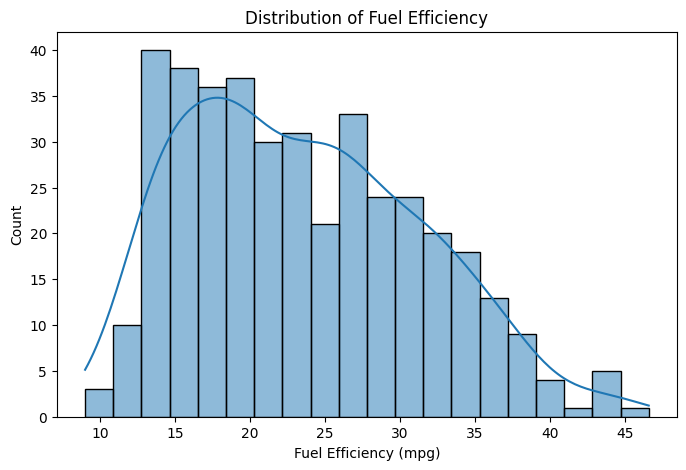

count    398.000000
mean      23.514573
std        7.815984
min        9.000000
25%       17.500000
50%       23.000000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64


In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram to see distribution
plt.figure(figsize=(8,5))
sns.histplot(data_frame['mpg'], bins=20, kde=True)
plt.xlabel('Fuel Efficiency (mpg)')
plt.ylabel('Count')
plt.title('Distribution of Fuel Efficiency')
plt.show()

# Basic statistics
print(data_frame['mpg'].describe())

## Section 2 Data Exploration and Preparation
## Feature selection and engineering
### Create a heatmap to evaluate distribution and determine which variables have stronger effects on mpg.

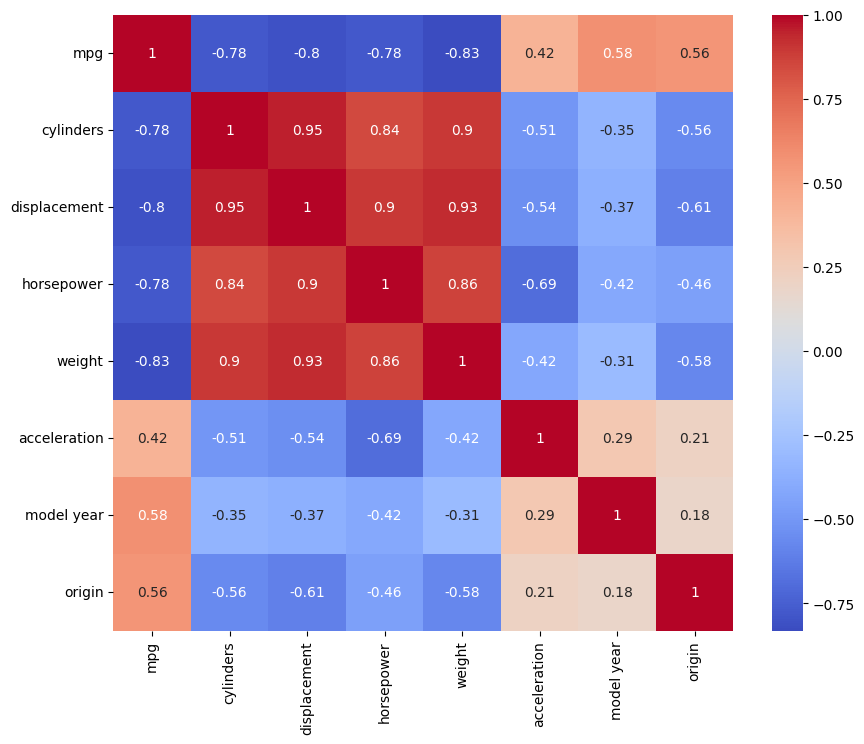

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = data_frame.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

### This heatmap shows which variables are highly inversely related to MPG. Weight, displacement, cylinders and horsepower are the most influential features for our model.

## Reflection 2: 
### What patterns or anomalies do you see? The variables that all factor into engine specifications are displacement, cylinders and horsepower. If we factor these in separately, we may run into issues with accuracy in our regression models.
### Do any features stand out? Weight appears to be the strongest predictor
### What preprocessing steps were necessary to clean and improve the data? The imputing and dropping of values was done at the beginning of Section 2.
### Did you create or modify any features to improve performance? I considered combining displacement, cylinders and horsepower into 1 variable, but research did not recommend that option. 



## Section 3. Feature Selection and Justification
### 3.1 Target variable is mpg. Since this is a numerical value, we will use a regression model. This will help us reach our goal of predicting fuel efficiency based on physical and engine-related characteristis.
### 3.2 Define X and y.  X = cylinders, displacement, horsepower, weight. y = mpg

## Reflection 3: 
### Why did you choose these features? The heatmap I created showed the strongest distributions in these features.
### How might they impact predictions or accuracy? These factors should provide strong predictability and accuracy based on the distribution levels they show. We know from basic physics that all of the features chosen strongly influence fuel efficiency.

## Section 4. Train a Model (Linear Regression)
### 4.1 Split the data into training and test sets using train_test_split (or StratifiedShuffleSplit if class imbalance is an issue).
### 4.2 Train model using Scikit-Learn model.fit() method

In [84]:
# Train/Test Split
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = data_frame[['cylinders', 'displacement', 'horsepower', 'weight']]
y = data_frame['mpg']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20,          # 20% test set
    random_state=42,         # makes results reproducible
)

print("Training set size:", len(X_train))
print("Test set size:", len(X_test))

Training set size: 318
Test set size: 80


In [ ]:
from sklearn.impute import SimpleImputer
import numpy as np

# Define features and target
X = data_frame[['cylinders', 'displacement', 'horsepower', 'weight']]
y = data_frame['mpg']

# Impute missing values using the median (impute missing values in horsepower)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

In [89]:
# Redo Train/Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)

In [90]:
from sklearn.linear_model import LinearRegression

# Create the model
lin_reg = LinearRegression()

# Train the model
lin_reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### 4.3 Evalulate performance, for example:
### Regression: R^2, MAE, RMSE (RMSE has been recently updated)

In [92]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# R² Score
r2 = r2_score(y_test, y_pred)

# MAE (Mean Absolute Error)
mae = mean_absolute_error(y_test, y_pred)

# RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", round(r2, 4))
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))


R²: 0.7271
MAE: 3.1192
RMSE: 3.8302


## Reflection 4: 
## How well did the model perform? This model performed well. R² of 72.7% shows that our model explained a variance in fuel efficiency of 73%. Both MAE & RMSE of 3-4 indicates that our model predicts fuel efficiency within a range of only 3-4 mpg, which I feel is pretty good considering so many factors could skew our predictions.
## Any surprises in the results?  None

## Section 5. Improve the Model or Try Alternates (Implement Pipelines)

### 5.1 Pipeline 1: Imputer - StandardScaler - Linear Regression
### This pipeline fixes missing values, scales features and fits a Linear Regression model

In [94]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Pipeline 1
pipe1 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# Train
pipe1.fit(X_train, y_train)

# Predict
y_pred1 = pipe1.predict(X_test)

# Metrics
r2_1 = r2_score(y_test, y_pred1)
mae_1 = mean_absolute_error(y_test, y_pred1)
rmse_1 = np.sqrt(mean_squared_error(y_test, y_pred1))

### 5.1 Pipeline 2: Imputer - Polynomial Features (degree=3) - StandardScaler - Linear Regression
### This pipeline fixes missing values, generates polynomial features up to degree 3, scales them and fits Linear Regression to a nonlinear feature set. This helps us capture interactions between the engine spec features and weight.

In [95]:
from sklearn.preprocessing import PolynomialFeatures

# Pipeline 2
pipe2 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# Train
pipe2.fit(X_train, y_train)

# Predict
y_pred2 = pipe2.predict(X_test)

# Metrics
r2_2 = r2_score(y_test, y_pred2)
mae_2 = mean_absolute_error(y_test, y_pred2)
rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred2))

### 5.3 Compare performance of all models (Baseline, Pipeline 1 and Pipeline 2)

In [96]:
# Create a comparison table
import pandas as pd

results = pd.DataFrame({
    'Model': ['Baseline Linear Regression', 
              'Pipeline 1: Scaled Linear Regression',
              'Pipeline 2: Polynomial Deg=3'],
    
    'R²':   [r2, r2_1, r2_2],
    'MAE':  [mae, mae_1, mae_2],
    'RMSE': [rmse, rmse_1, rmse_2]
})

results


,Model,R²,MAE,RMSE
0,Baseline Linear Regression,0.727145,3.119195,3.830199
1,Pipeline 1: Scaled Linear Regression,0.727145,3.119195,3.830199
2,Pipeline 2: Polynomial Deg=3,0.780813,2.637229,3.432912


## Reflection 5: 
### Which models performed better? Pipeline 2 produced the best performance. It increased the R² to 78%, which is a better indicator of the variance in mpg. Pipeline 2 also improved the MAE AND RMSE, lowering the 3-4 mpg range to 2.6-3.4.
### How does scaling impact results? This comparison confirmed that scaling does not improve accuracy in Linear Regression models. 

## Section 6. Final Thoughts & Insights

### 6.1 Summarize findings
Our goal was to predict a car's fuel efficiency using the characteristics of both engine specifications and weight of the vehicle. We found that weight is the strongest indicator, with horsepower, displacement and cylinders all having high correlations with fuel efficiency. Our best performing model was a Polynomial Regression Model (Pipeline 2 with degree =3). 

### 6.2 Discuss challenges faced.  
This dataset had a few missing data issues which were easily corrected by imputing and dropping variables. The bigger issue was deciding how to use the engine specification features that showed high correlations. I considered whether they should be combined into one feature, but research showed that was not the best option as it would destabilize the data, giving us inaccurate model results.

### 6.3 If you had more time, what would you try next?
I think it would be fun to actually try combining the engine spec features. I would also like to continue trying other possible models.

## Reflection 6- What did you learn from this project?
This project was very fun and much easier than I anticipated. I was really pleased at how smoothly it went and how much I learned about the factors that might effect models we choose. 